# Comparing two versions of EoMT
One trained on the Cityscapes dataset, another one on the COCO

## Setup

In [24]:
import sys
import os
import torch
import matplotlib.pyplot as plt
import numpy as np

# Add root and eomt to path
root_path = os.path.abspath(".")
if root_path not in sys.path:
    sys.path.insert(0, root_path)

import eomt_setup
import eomt_inference

device = eomt_setup.setup_environment(eomt_path="eomt")

img_idx = 0 # Visualize the first image in the dataset
config_path_cityscapes = "eomt/configs/dinov2/cityscapes/semantic/eomt_base_640.yaml"
config_path_coco = "eomt/configs/dinov2/coco/panoptic/eomt_base_640_2x.yaml"
weights_path_cityscapes = "eomt/weights/eomt_cityscapes.bin"
weights_path_coco = "eomt/weights/eomt_coco.bin"
IGNORE_INDEX = 255

## 1. CityScapes EoMT (Semantic Segmentation)
First, we load the model trained on CityScapes and run semantic inference.

Loading Cityscapes Model...
Loaded weights from eomt/weights/eomt_cityscapes.bin


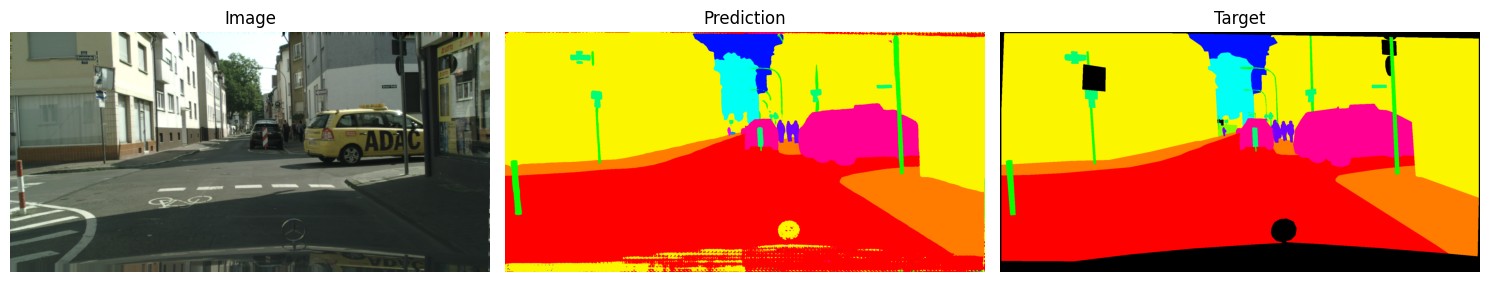

In [25]:
print("Loading Cityscapes Model...")
config_cs = eomt_setup.load_config(config_path_cityscapes)
data_cs = eomt_setup.setup_data(config_cs, data_path="datasets/cityscapes")
model_cs = eomt_setup.load_model(config_cs, data_cs, device, weights_path=weights_path_cityscapes)

img, target = data_cs.val_dataloader().dataset[img_idx]
pred_array, target_array = eomt_inference.infer_semantic(model_cs, img, target, device, data_cs.img_size, IGNORE_INDEX)
eomt_inference.plot_semantic_results(img, pred_array, target_array, IGNORE_INDEX)

## 2. COCO EoMT (Panoptic Segmentation)
Next, we load the model trained on COCO and run panoptic inference. 
Note: This model can also perform semantic inference.

Loading COCO Model...
Loaded weights from eomt/weights/eomt_coco.bin
Semantic Prediction Unique Values (COCO IDs): [  0   2 100 116 119 123 129 133]
Semantic Target Unique Values (Cityscapes IDs): [-1  0  1  2  4  5  7  8 10 11 13]
Mapped Semantic Prediction Unique Values (Cityscapes Train IDs): [  0   1   2   8  10  11  13 255]


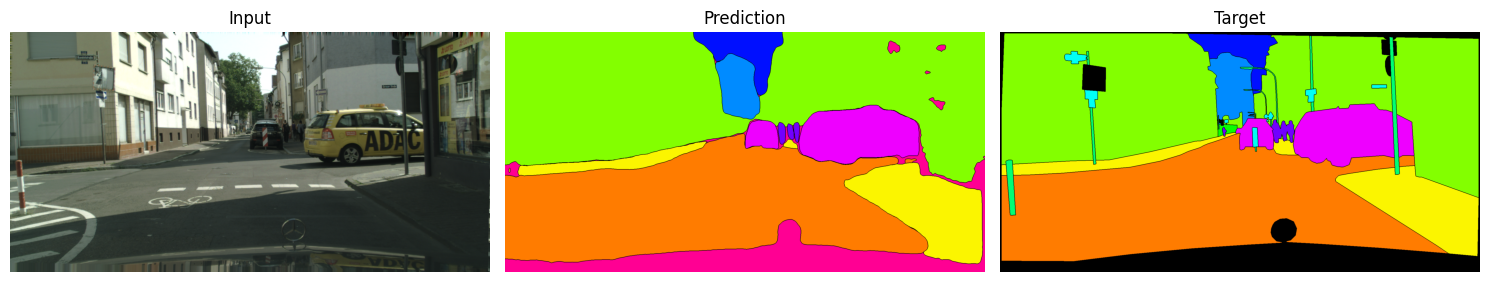

In [ ]:
import importlib
importlib.reload(eomt_setup)
importlib.reload(eomt_inference)

print("Loading COCO Model...")
config_coco = eomt_setup.load_config(config_path_coco)
data_coco = eomt_setup.setup_data(config_coco, data_path="datasets/cityscapes")

cpu_device = torch.device("cpu")
model_coco = eomt_setup.load_model(config_coco, data_coco, cpu_device, weights_path=weights_path_coco)
model_coco = model_coco.to(device=device, dtype=torch.float32)

img, target = data_coco.val_dataloader().dataset[img_idx]
sem_pred, inst_pred, sem_target, inst_target = eomt_inference.infer_panoptic(model_coco, img, target, device)
# Map COCO semantic predictions to Cityscapes train IDs for color consistency
sem_pred = eomt_inference.map_coco_preds_to_cityscapes(sem_pred)
eomt_inference.plot_panoptic_results(model_coco, img, sem_pred, inst_pred, sem_target, inst_target)

## 3. COCO EoMT (Semantic Segmentation)
Running semantic inference with the COCO model on the same Cityscapes image.

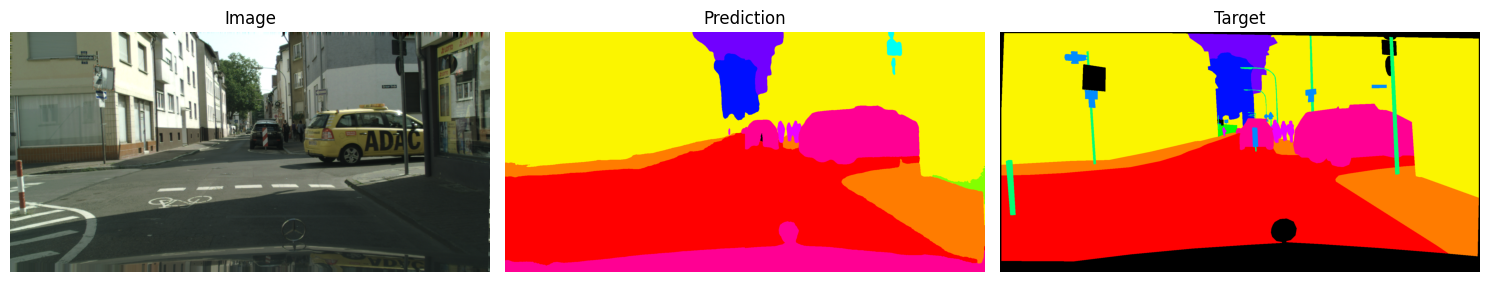

In [27]:
img, target = data_coco.val_dataloader().dataset[img_idx]
sem_pred, sem_target = eomt_inference.infer_semantic(model_coco, img, target, device, data_coco.img_size, IGNORE_INDEX)
sem_pred = eomt_inference.map_coco_preds_to_cityscapes(sem_pred)
eomt_inference.plot_semantic_results(img, sem_pred, sem_target, IGNORE_INDEX)

In [ ]:
cs_mIoU, cs_ious = eomt_inference.evaluate_semantic(model_cs, data_cs.val_dataloader(), device, data_cs.img_size, num_classes=19, ignore_index=255, is_coco=False, limit=2)
coco_mIoU, coco_ious = eomt_inference.evaluate_semantic(model_coco, data_coco.val_dataloader(), device, data_coco.img_size, num_classes=19, ignore_index=255, is_coco=True, limit=2)

## 4. Evaluation on the validation dataset

In [28]:
print(f"Evaluating the COCO model...")
coco_mIoU, coco_ious = eomt_inference.evaluate_semantic(model_coco, data_coco.val_dataloader(), device, data_coco.img_size, num_classes=19, ignore_index=255, is_coco=True)

Evaluating 500 images for COCO.


In [31]:
coco_mIoU

tensor(0.5175, dtype=torch.float64)